# Global Epistasis: Nonlinear Link Function Comparison

Compare link functions (global epistasis models) & export latent linearized phenotypes for epistasis inference.

In [1]:
# Configuration cell
VERSION = 1  # 1 = use all data; 2 = restrict to S75G (S56G in Tharp et al, 2026) == 1
INFILE = '../../../datasets_for_inference/expression_epistasis.csv'
GENO_COL = 'geno'
PHENO_COL = 'expr_mednorm_mean'
ANTIGEN = 'expression'

# use reference-based encoding for reference-based linear interaction models and reference-free encoding for reference-free linear interaction models
ENCODING = 'biochem'  # 'biochem' => 0/1 (reference-based encoding); 'stat' => -1/+1 (reference-free encoding)

PIN_VALUE = 7.0       # detection limit in -log10Kd
EPS_SEM = 1e-6        # floor to avoid divide-by-zero in sigma

EXPORT_FUNCTIONS = ['all']  # or e.g. ['hill', 'logistic']

print(f'Configuration: VERSION={VERSION}, INFILE={INFILE}, ANTIGEN={ANTIGEN}, ENCODING={ENCODING}')


Configuration: VERSION=1, INFILE=../../../datasets_for_inference/expression_epistasis.csv, ANTIGEN=expression, ENCODING=biochem


In [2]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit, brentq
from scipy.interpolate import BSpline
from scipy.optimize import lsq_linear

from sklearn.linear_model import LinearRegression

print('Dependencies loaded')

Dependencies loaded


In [3]:
# Load and clean data
df = pd.read_csv(INFILE)

# clean genotypes column: keep only 0/1 characters, remove whitespace, and drop rows with empty genotypes after cleaning
df[GENO_COL] = df[GENO_COL].astype(str).str.strip().str.replace(r'[^01]', '', regex=True)
df = df.loc[df[GENO_COL].str.len() > 0].copy()

L = int(df[GENO_COL].str.len().max())
df[GENO_COL] = df[GENO_COL].str.zfill(L)

pos4_col = 'pos4'
if pos4_col not in df.columns:
    raise KeyError("Column 'pos4' not found in input CSV; required for VERSION=2 filtering")
df[pos4_col] = df[pos4_col].astype(int)

if PHENO_COL not in df.columns:
    raise KeyError(f"Phenotype column '{PHENO_COL}' not found in {INFILE}")

y_all = df[PHENO_COL].to_numpy(dtype=float)

SEM_COL = PHENO_COL.replace('_mean', '_sem') if PHENO_COL.endswith('_mean') else PHENO_COL + '_sem'
if SEM_COL not in df.columns:
    raise KeyError(f"SEM column '{SEM_COL}' not found; needed for weighted fits")

sem_all = df[SEM_COL].to_numpy(dtype=float)

pinned_all = (df[PHENO_COL] == PIN_VALUE)

nonpinned_sem = sem_all[~pinned_all]
nonpinned_sem = nonpinned_sem[np.isfinite(nonpinned_sem)]
if len(nonpinned_sem) == 0:
    raise ValueError("No non-pinned SEM values found to compute median SEM.")

# calculate median SEM among non-pinned genotypes to use as a proxy for the SEM of pinned genotypes
## since pinned genotypes have no measurable binding, their SEM is not defined, but we want to carry some notion of uncertainty through the fitting process so that the pinned values don't dominate the first-order linear model fit
median_sem_nonpinned = float(np.median(nonpinned_sem))

# set the SEM of pinned genotypes to the median SEM of non-pinned genotypes, and apply a floor to avoid zero SEM (which would cause divide-by-zero erros when we fit the first-order linear model)
sem_adj_all = sem_all.copy()
sem_adj_all[pinned_all] = median_sem_nonpinned
sem_adj_all = np.maximum(sem_adj_all, EPS_SEM)

print(f'Loaded {len(df)} genotypes, L={L}')
print(f'Pinned count: {int(np.sum(pinned_all))}')
print(f'Median SEM (non-pinned): {median_sem_nonpinned:.6g}')
print(f"pos4==1 count (full df): {int(np.sum(df[pos4_col] == 1))}")

if VERSION == 2:
    mask_scope = (df[pos4_col] == 1)
    df_sub = df.loc[mask_scope].copy()
    y = y_all[mask_scope]
    pinned = pinned_all[mask_scope]
    sem_adj = sem_adj_all[mask_scope]
    fit_desc = f'VERSION 2: pos4==1 subset ({len(df_sub)} rows)'
elif VERSION == 1:
    df_sub = df.copy()
    y = y_all
    pinned = pinned_all
    sem_adj = sem_adj_all
    fit_desc = f'VERSION 1: all data ({len(df_sub)} rows)'
else:
    raise ValueError(f'Invalid VERSION: {VERSION}')

print(fit_desc)

Loaded 8150 genotypes, L=13
Pinned count: 0
Median SEM (non-pinned): 0.0836222
pos4==1 count (full df): 4083
VERSION 1: all data (8150 rows)


In [4]:
# masks for pinned and finite values for additive model fit
pinned_np = np.asarray(pinned, dtype=bool)
mask_finite = np.isfinite(y)

# VERSION 1 includes all finite rows, including pinned genotypes
if VERSION == 1:
    mask_use = mask_finite
    mask_fit_add = mask_finite
    mask_fit_g   = mask_finite
    note = "VERSION=1: using all finite rows (including pinned)"

# VERSION 2 restricts to pos4==1 subset and excludes pinned genotypes from fitting    
elif VERSION == 2:
    mask_use = mask_finite & (~pinned_np)
    mask_fit_add = mask_use
    mask_fit_g   = mask_use
    note = "VERSION=2: pos4-only, excluding pinned everywhere"
else:
    raise ValueError(f"Invalid VERSION: {VERSION}")

print(note)
print(f"Rows used: {int(mask_use.sum())}")

# form a design matrix for the additive model fit, using either reference-based encoding (0/1) or reference-free encoding (-1/+1)
X_sites = np.array([[int(c) for c in g] for g in df_sub[GENO_COL]], dtype=int)

if ENCODING == 'biochem':
    X_add_enc = X_sites.astype(float)   
elif ENCODING == 'stat':
    X_add_enc = (2 * X_sites - 1).astype(float)
else:
    raise ValueError("ENCODING must be 'biochem' or 'stat'")

# subsets the design matrix and phenotype vector for fitting the additive model
X_fit_add = X_add_enc[mask_fit_add]
y_fit_add = y[mask_fit_add]

# fit the additive model on the specified subset of the data
model_add = LinearRegression(fit_intercept=True)
model_add.fit(X_fit_add, y_fit_add)

# use the fitted additve model to predict phenotypes for all genotypes in the dataset (including those not used for fitting)
x_add = model_add.predict(X_add_enc)

print(f"Additive model fit on {len(y_fit_add)} rows")
print(f"x_add range: [{x_add.min():.3f}, {x_add.max():.3f}]")
print(f'y range:     [{np.nanmin(y):.3f}, {np.nanmax(y):.3f}]')


VERSION=1: using all finite rows (including pinned)
Rows used: 8150
Additive model fit on 8150 rows
x_add range: [4.112, 4.429]
y range:     [3.387, 4.710]


In [5]:
# masks for global (nonlinear) model fit
pinned_np = np.asarray(pinned, dtype=bool)
mask_finite = np.isfinite(y)

if VERSION == 1:
    mask_fit_g = mask_finite                      
elif VERSION == 2:
    mask_fit_g = mask_finite & (~pinned_np)        
else:
    raise ValueError(f"Invalid VERSION: {VERSION}")

# additive predicted phenotypes
x_fit = x_add[mask_fit_g]

# observed phenotpyes
y_fit = y[mask_fit_g]

print("Nonlinear g(x) fit:")
print(f"  rows = {len(x_fit)}")
print(f"  x range = [{x_fit.min():.3f}, {x_fit.max():.3f}]")
print(f"  y range = [{y_fit.min():.3f}, {y_fit.max():.3f}]")



Nonlinear g(x) fit:
  rows = 8150
  x range = [4.112, 4.429]
  y range = [3.387, 4.710]


Non-linear (link) functions for global epistasis inference

In [6]:
# Power-law function: g(x) = C + L * (x - x0)^lambda
# L > 0 enforces monotone increasing; x0 shifts origin so (x - x0) > 0 over the data range
def g_power(x, lmbda, x0, L, C):
    return C + L * np.power(np.maximum(x - x0, 1e-12), lmbda)

# Logistic function: g(x) = L / (1 + exp(-k*(x-x0))) + C
def g_logistic(x, L, k, x0, C):
    return L / (1.0 + np.exp(-k * (x - x0))) + C

# Exponential saturation function: g(x) = C + L * (1 - exp(-k*(x-x0)))
def g_expsat(x, C, L, k, x0):
    return C + L * (1.0 - np.exp(-k * np.maximum(0.0, x - x0)))

# Hill function: g(x) = C + L * (x^n / (x^n + x0^n))
def g_hill(x, C, L, x0, n):
    z = np.maximum(1e-8, x0)
    r = np.power(np.maximum(1e-8, x) / z, np.maximum(1e-8, n))
    return C + L * (r / (1.0 + r))

print('Link functions defined')

Link functions defined


I-spline link function builder

In [7]:
# set knot locations for spline fit using quantiles of the additive predictions, with extra knots at the boundaries to ensure good behavior at the edges of the data
def _quantile_knots(x, n_knots, degree):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    xmin, xmax = float(np.min(x)), float(np.max(x))
    if xmax == xmin:
        xmax = xmin + 1.0
    xs = (x - xmin) / (xmax - xmin)
    qs = np.linspace(0, 1, n_knots)
    interior = np.quantile(xs, qs)[1:-1]
    knots = np.concatenate([
        np.full(degree + 1, 0.0),
        interior,
        np.full(degree + 1, 1.0)
    ])
    return knots, xmin, xmax

# construct M-spline basis functions from B-splines, which can then be integrated to get I-spline basis functions for monotone spline fitting
def _mspline_from_bspline(knots, degree):
    n_basis = len(knots) - degree - 1
    coeffs = np.eye(n_basis)
    grid = np.linspace(0.0, 1.0, 200)
    Ms = []
    for i in range(n_basis):
        bs = BSpline(knots, coeffs[i], degree, extrapolate=False)
        vals = np.maximum(0.0, bs(grid))
        area = np.trapezoid(vals, grid) if hasattr(np, 'trapezoid') else np.trapz(vals, grid)
        if area <= 1e-12:
            vals[:] = 0.0
        else:
            vals /= area
        Ms.append(vals)
    Ms = np.stack(Ms, axis=1)
    return grid, Ms

# compute I-spline basis functions for monotone spline fitting by integrating the M-spline basis functions, and evaluate the I-spline basis functions at the given x values using linear interpolation
def _ispline_matrix(x, knots, degree):
    from scipy.integrate import cumulative_trapezoid
    from scipy.interpolate import interp1d
    grid, Ms = _mspline_from_bspline(knots, degree)
    n_basis = Ms.shape[1]
    Is_grid = np.zeros_like(Ms)
    for j in range(n_basis):
        ct = cumulative_trapezoid(Ms[:, j], grid, initial=0.0)
        # normalize so each I-spline reaches 1.0 at the right boundary
        ct_max = ct[-1]
        Is_grid[:, j] = ct / ct_max if ct_max > 1e-12 else ct

    X = np.zeros((len(x), n_basis))
    for j in range(n_basis):
        f = interp1d(grid, Is_grid[:, j], kind='linear', bounds_error=False,
                     fill_value=(0.0, Is_grid[-1, j]))
        X[:, j] = f(x)
    return X

In [8]:
def fit_ispline(x, y, sigma=None, n_knots=12, degree=3):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if sigma is not None:
        sigma = np.asarray(sigma, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    if sigma is not None:
        mask = mask & np.isfinite(sigma)

    x = x[mask]
    y = y[mask]
    if sigma is not None:
        sigma = np.maximum(sigma[mask], EPS_SEM)

    # Build quantile-based knot vector and normalize x to [0,1]
    knots, xmin, xmax = _quantile_knots(x, n_knots, degree)
    xs = (x - xmin) / (xmax - xmin + 1e-12)
    xs = np.clip(xs, 0.0, 1.0)

    # Build I-spline design matrix
    A = _ispline_matrix(xs, knots, degree)

    # Shift and scale y to [0, 1] so that nonneg-constrained coefficients
    # can span the full observed range. Unconstrained shift/scale are
    # recovered analytically after the solve.
    y_lo = float(np.min(y))
    y_hi = float(np.max(y))
    y_rng = max(y_hi - y_lo, 1e-8)
    y_scaled = (y - y_lo) / y_rng   # now in [0, 1]

    # Optional weights
    if sigma is not None:
        w = 1.0 / sigma
        w_norm = w / np.sum(w)
        A_w = A * w[:, None]
        y_w = y_scaled * w
    else:
        w_norm = None
        A_w = A
        y_w = y_scaled

    # Fit nonneg coefficients (preserves monotonicity) in scaled space
    sol = lsq_linear(A_w, y_w, bounds=(0.0, np.inf), lsmr_tol='auto')
    coefs_scaled = sol.x

    # Fit intercept in scaled space (unconstrained)
    fitted_scaled = A @ coefs_scaled
    if sigma is not None:
        intercept_scaled = float(np.sum(w_norm * (y_scaled - fitted_scaled)))
    else:
        intercept_scaled = float(np.mean(y_scaled - fitted_scaled))

    # Rescale coefficients and intercept back to original y units
    coefs = coefs_scaled * y_rng
    intercept = intercept_scaled * y_rng + y_lo

    return (knots, coefs, intercept, degree, xmin, xmax)


# Use the learned global epistasis function (i-spline curve) to convert additive phenotypes into predicted observed phenotypes
def g_ispline(x, knots, coefs, intercept, degree, xmin=None, xmax=None):
    x = np.asarray(x, dtype=float)

    if xmin is None:
        xmin = 0.0
    if xmax is None:
        xmax = 1.0

    # Normalize x to [0,1] using the training range
    xs = (x - xmin) / (xmax - xmin + 1e-12)
    xs = np.clip(xs, 0.0, 1.0)

    # Build I-spline basis matrix and return predictions
    A = _ispline_matrix(xs, knots, degree)
    return A @ coefs + intercept

Invert any of the nondecreasing monotonic link functions using linear interpolation

We prefer linear interpolation because it allows us to robustly invert all of our tested link functions - i-splines cannot be analytically inverted, so this approach ensures each function is inverted in the same manner

In [9]:
# helper function to create a monotone grid of x values and corresponding g(x) values for plotting the learned global epistasis function, using the specified link function and the range of x values observed in the data
def make_monotone_grid(forward, x_min, x_max, n=4000, pad=10.0):
    lo = float(x_min - pad)
    hi = float(x_max + pad)
    xg = np.linspace(lo, hi, n)
    yg = forward(xg)
    yg = np.maximum.accumulate(yg)
    return xg, yg

# helper function to compute the inverse of a monotone function defined by a grid of x and g(x) values, using linear interpolation
def inv_monotone_interp(xg, yg, y0):
    if y0 <= yg[0]:
        return float(xg[0])
    if y0 >= yg[-1]:
        return float(xg[-1])
    return float(np.interp(y0, yg, xg))


Now use ordinary nonlinear regression (least-squares) to infer the best fit for each non-linear link function to the predicted (additive) and observed phenotypes, print plots showing each fit (with perfomance) and output the latent linear phenotypes from each fit

*note: we do not weight fits by error (sigma) for this analysis because error becomes arbitrary for fitting pinned values (VERSION 1) and we want to compare fits equivalently (VERSION 2)

x_fit range: [4.112, 4.429]  (rng=0.317)
y_fit range: [3.387, 4.710]  (rng=1.323)
Fitting power function (constrained)...
  residual R² = 0.2616
  Pearson r²  = 0.2616
Fitting logistic function (monotone)...
  residual R² = 0.3728
  Pearson r²  = 0.3728
Fitting exponential-saturation function (monotone)...
  residual R² = 0.3692
  Pearson r²  = 0.3692
Fitting Hill function (monotone)...
  residual R² = 0.2027
  Pearson r²  = 0.2027
Fitting I-spline (monotone by construction)...
  residual R² = 0.3675
  Pearson r²  = 0.3682

Successfully fitted 5 functions
power
  params: {'lmbda': np.float64(0.05000000000000011), 'x0': np.float64(4.111496787735852), 'L': np.float64(3.62676169018281), 'C': np.float64(0.9785688441561426)}
  residual R² = 0.2616
  Pearson r²  = 0.2616
logistic
  params: {'L': np.float64(0.6043687271347249), 'k': np.float64(63.069263484217736), 'x0': np.float64(4.162851948755171), 'C': np.float64(3.7029168057409034)}
  residual R² = 0.3728
  Pearson r²  = 0.3728
exp_sat
  

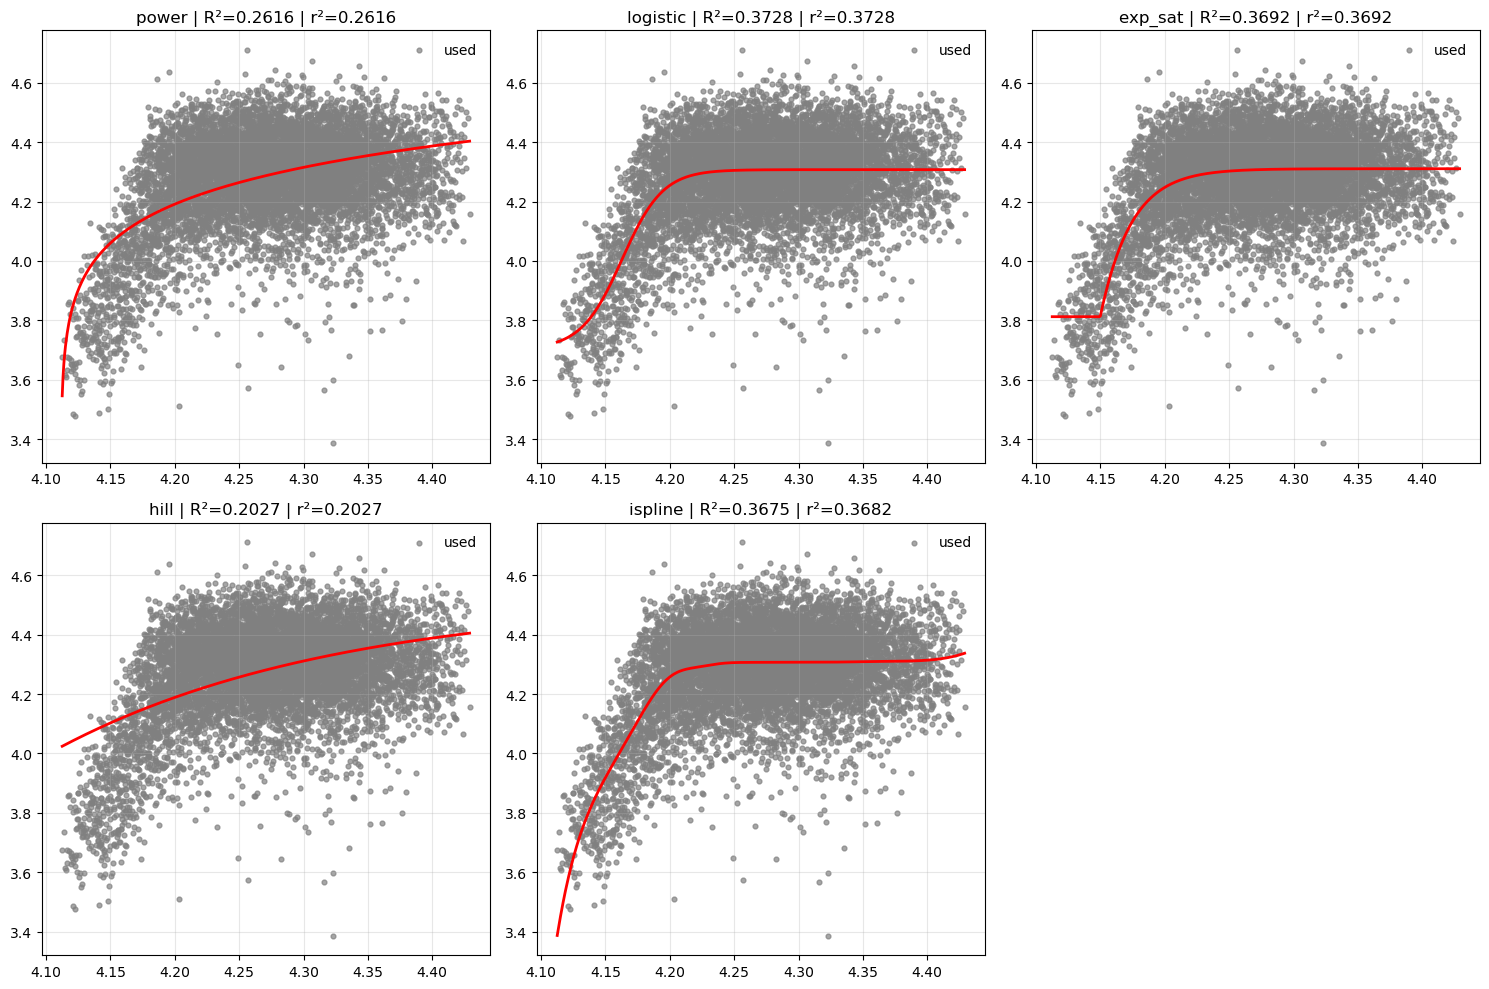

Saved: expression_nonlinear_comparison_v1_biochem.png
Will export: ['power', 'logistic', 'exp_sat', 'hill', 'ispline']
Linearizing power (scoped)...
Linearizing logistic (scoped)...
Linearizing exp_sat (scoped)...
Linearizing hill (scoped)...
Linearizing ispline (scoped)...
Complete: 5 functions
Saved: expression_epistasis_linearized_power_v1_biochem.csv (rows=8150, version=1, encoding=biochem)
Saved: expression_epistasis_linearized_logistic_v1_biochem.csv (rows=8150, version=1, encoding=biochem)
Saved: expression_epistasis_linearized_exp_sat_v1_biochem.csv (rows=8150, version=1, encoding=biochem)
Saved: expression_epistasis_linearized_hill_v1_biochem.csv (rows=8150, version=1, encoding=biochem)
Saved: expression_epistasis_linearized_ispline_v1_biochem.csv (rows=8150, version=1, encoding=biochem)


In [10]:
# compute ranges and medians for additive predictions (x) and observed phenotypes (y) for the subset of the data used in the nonlinear fit, ignoring non-finite values
def _finite_minmax(a):
    a = np.asarray(a, dtype=float)
    a = a[np.isfinite(a)]
    return float(np.min(a)), float(np.max(a))

x_min, x_max = _finite_minmax(x_fit)
y_min, y_max = _finite_minmax(y_fit)
x_med = float(np.nanmedian(x_fit))
y_med = float(np.nanmedian(y_fit))
x_rng = max(x_max - x_min, 1e-6)
y_rng = max(y_max - y_min, 1e-6)

print(f"x_fit range: [{x_min:.3f}, {x_max:.3f}]  (rng={x_rng:.3f})")
print(f"y_fit range: [{y_min:.3f}, {y_max:.3f}]  (rng={y_rng:.3f})")

# Fit candidate monotone link functions g(x)
results = []

# Total sum of squares for residual-based R^2
ss_tot = np.sum((y_fit - np.mean(y_fit))**2)

# Power-law function: g(x) = C + L * (x - x0)^lambda
# x0 < x_min so (x - x0) is always positive; L > 0 enforces monotone increasing
print('Fitting power function (constrained)...')
try:
    # x0 must be below x_min so the shift (x - x0) is always positive
    x0_upper = x_min - 1e-3
    x0_lower = x_min - 5.0 * x_rng

    # Multi-start grid over (lambda, x0) to avoid local minima
    best_popt, best_res = None, np.inf
    for lmbda0 in [0.3, 0.5, 1.0, 1.5, 2.5]:
        for x0_frac in [0.1, 0.5, 0.9]:
            x0_0 = x0_lower + x0_frac * (x0_upper - x0_lower)
            p0_try = [lmbda0, x0_0, y_rng, y_min]
            try:
                bounds = (
                    [0.05, x0_lower,  0.0,        -np.inf],
                    [10.0, x0_upper,  np.inf,      np.inf]
                )
                popt_try, _ = curve_fit(
                    g_power, x_fit, y_fit,
                    p0=p0_try, bounds=bounds,
                    maxfev=200000
                )
                res = np.sum((y_fit - g_power(x_fit, *popt_try))**2)
                if res < best_res:
                    best_res, best_popt = res, popt_try
            except Exception:
                pass
    if best_popt is None:
        raise RuntimeError("All starting points failed for power function")
    popt = best_popt

    y_pred = g_power(x_fit, *popt)
    ss_res = np.sum((y_fit - y_pred)**2)
    r2_resid = float(1.0 - ss_res / ss_tot)
    r2_corr = float(np.corrcoef(y_fit, y_pred)[0, 1]**2)

    results.append({
        'name': 'power',
        'params': {'lmbda': popt[0], 'x0': popt[1], 'L': popt[2], 'C': popt[3]},
        'r2_resid': r2_resid,
        'r2_corr': r2_corr
    })

    print(f'  residual R² = {r2_resid:.4f}')
    print(f'  Pearson r²  = {r2_corr:.4f}')
except Exception as e:
    print(f'  Failed: {e}')

#Logistic function (nondecreasing and monotonic for L>0 and k>0)
print('Fitting logistic function (monotone)...')
try:
    # Initial guesses: amplitude, slope, midpoint, baseline
    p0 = [y_rng, 1.0 / max(1e-6, x_rng), x_med, y_min]

    # Bounds enforce increasing sigmoid
    bounds = ([0.0, 1e-8, x_min - 0.5 * x_rng, y_min - 5.0 * y_rng],
              [np.inf, np.inf, x_max + 0.5 * x_rng, y_max + 5.0 * y_rng])

    popt, _ = curve_fit(
        g_logistic, x_fit, y_fit,
        p0=p0, bounds=bounds,
        # sigma=sigma_fit, absolute_sigma=False,
        maxfev=100000
    )

    y_pred = g_logistic(x_fit, *popt)
    ss_res = np.sum((y_fit - y_pred)**2)
    r2_resid = float(1.0 - ss_res / ss_tot)
    r2_corr = float(np.corrcoef(y_fit, y_pred)[0, 1]**2)

    results.append({
        'name': 'logistic',
        'params': {'L': popt[0], 'k': popt[1], 'x0': popt[2], 'C': popt[3]},
        'r2_resid': r2_resid,
        'r2_corr': r2_corr
    })

    print(f'  residual R² = {r2_resid:.4f}')
    print(f'  Pearson r²  = {r2_corr:.4f}')
except Exception as e:
    print(f'  Failed: {e}')

# Exponential saturation function (nondecreasing and monotonic for k>0)
print('Fitting exponential-saturation function (monotone)...')
try:
    # Initial guesses: baseline, amplitude, rate, threshold
    p0 = [y_min, y_rng, 1.0 / max(1e-6, x_rng), x_min]

    # Bounds enforce increasing saturating behavior
    bounds = ([y_min - 5.0 * y_rng, 0.0, 1e-8, x_min - 0.5 * x_rng],
              [y_max + 5.0 * y_rng, np.inf, np.inf, x_max + 0.5 * x_rng])

    popt, _ = curve_fit(
        g_expsat, x_fit, y_fit,
        p0=p0, bounds=bounds,
        # sigma=sigma_fit, absolute_sigma=False,
        maxfev=100000
    )

    y_pred = g_expsat(x_fit, *popt)
    ss_res = np.sum((y_fit - y_pred)**2)
    r2_resid = float(1.0 - ss_res / ss_tot)
    r2_corr = float(np.corrcoef(y_fit, y_pred)[0, 1]**2)

    results.append({
        'name': 'exp_sat',
        'params': {'C': popt[0], 'L': popt[1], 'k': popt[2], 'x0': popt[3]},
        'r2_resid': r2_resid,
        'r2_corr': r2_corr
    })

    print(f'  residual R² = {r2_resid:.4f}')
    print(f'  Pearson r²  = {r2_corr:.4f}')
except Exception as e:
    print(f'  Failed: {e}')

# Hill function (nondecreasing and monotonic for L>0, x0>0, n>0)
print('Fitting Hill function (monotone)...')
try:
    # Hill uses x/x0, so x0>0 and n>0 are required
    p0 = [y_min, y_rng, max(1e-3, x_med), 2.0]

    bounds = ([y_min - 5.0 * y_rng, 0.0, 1e-8, 1e-6],
              [y_max + 5.0 * y_rng, np.inf, np.inf, 20.0])

    popt, _ = curve_fit(
        g_hill, x_fit, y_fit,
        p0=p0, bounds=bounds,
        # sigma=sigma_fit, absolute_sigma=False,
        maxfev=100000
    )

    y_pred = g_hill(x_fit, *popt)
    ss_res = np.sum((y_fit - y_pred)**2)
    r2_resid = float(1.0 - ss_res / ss_tot)
    r2_corr = float(np.corrcoef(y_fit, y_pred)[0, 1]**2)

    results.append({
        'name': 'hill',
        'params': {'C': popt[0], 'L': popt[1], 'x0': popt[2], 'n': popt[3]},
        'r2_resid': r2_resid,
        'r2_corr': r2_corr
    })

    print(f'  residual R² = {r2_resid:.4f}')
    print(f'  Pearson r²  = {r2_corr:.4f}')
except Exception as e:
    print(f'  Failed: {e}')

# I-spline (nondecreasing and monotonic by construction)
print('Fitting I-spline (monotone by construction)...')
try:
    knots, coefs, intercept, degree, xmin, xmax = fit_ispline(
        x_fit, y_fit, n_knots=12, degree=3
    )

    y_pred = g_ispline(x_fit, knots, coefs, intercept, degree, xmin, xmax)
    ss_res = np.sum((y_fit - y_pred)**2)
    r2_resid = float(1.0 - ss_res / ss_tot)
    r2_corr = float(np.corrcoef(y_fit, y_pred)[0, 1]**2)

    results.append({
        'name': 'ispline',
        'params': {
            'knots': knots,
            'coefs': coefs,
            'intercept': intercept,
            'degree': degree,
            'xmin': xmin,
            'xmax': xmax
        },
        'r2_resid': r2_resid,
        'r2_corr': r2_corr
    })

    print(f'  residual R² = {r2_resid:.4f}')
    print(f'  Pearson r²  = {r2_corr:.4f}')
except Exception as e:
    print(f'  Failed: {e}')

print(f'\nSuccessfully fitted {len(results)} functions')
for r in results:
    print(r['name'])
    print('  params:', r['params'])
    print(f"  residual R² = {r['r2_resid']:.4f}")
    print(f"  Pearson r²  = {r['r2_corr']:.4f}")

# Compare fitted link functions
print('\n' + '=' * 80)
print('LINK FUNCTION COMPARISON RESULTS (sorted by residual R²)')
print('=' * 80)
for res in sorted(results, key=lambda x: x['r2_resid'], reverse=True):
    print(f"{res['name'].upper():10s} | residual R² = {res['r2_resid']:.4f} | Pearson r² = {res['r2_corr']:.4f}")
print('=' * 80)

# Plot candidate fits
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

xx = np.linspace(float(np.min(x_add)), float(np.max(x_add)), 500)

mask_use_np = np.asarray(mask_use, dtype=bool)
pinned_np = np.asarray(pinned, dtype=bool)
mask_pinned = pinned_np & np.isfinite(y)
mask_excluded = (~mask_use_np) & np.isfinite(y)

for idx, res in enumerate(results):
    if idx >= len(axes):
        break

    ax = axes[idx]
    name = res['name']
    params = res['params']
    r2_resid = res['r2_resid']
    r2_corr = res['r2_corr']

    # Plot rows used for GE fit / inversion
    ax.scatter(
        x_add[mask_use_np],
        y[mask_use_np],
        s=12,
        alpha=0.7,
        color='0.5',
        label='used'
    )

    # Evaluate fitted curve
    if name == 'power':
        yy = g_power(xx, params['lmbda'], params['x0'], params['L'], params['C'])
    elif name == 'logistic':
        yy = g_logistic(xx, params['L'], params['k'], params['x0'], params['C'])
    elif name == 'exp_sat':
        yy = g_expsat(xx, params['C'], params['L'], params['k'], params['x0'])
    elif name == 'hill':
        yy = g_hill(xx, params['C'], params['L'], params['x0'], params['n'])
    elif name == 'ispline':
        yy = g_ispline(
            xx,
            params['knots'],
            params['coefs'],
            params['intercept'],
            params['degree'],
            params['xmin'],
            params['xmax']
        )
    else:
        yy = np.full_like(xx, np.nan)

    ax.plot(xx, yy, color='red', lw=2)
    ax.set_title(f"{name} | R²={r2_resid:.4f} | r²={r2_corr:.4f}")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)

for idx in range(len(results), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(f'{ANTIGEN}_nonlinear_comparison_v{VERSION}_{ENCODING}.png', dpi=150)
plt.show()
print(f'Saved: {ANTIGEN}_nonlinear_comparison_v{VERSION}_{ENCODING}.png')

# Determine which fitted functions to export
available = [res['name'] for res in results]

if 'all' in EXPORT_FUNCTIONS:
    export_list = available
else:
    export_list = [name for name in EXPORT_FUNCTIONS if name in available]
    missing = [name for name in EXPORT_FUNCTIONS if name not in available]
    if missing:
        print(f"Warning: requested but not fitted: {missing}")

print(f'Will export: {export_list}')

# Linearize phenotype using inverse of each selected link function
linearized_map = {}

idx_use = np.where(mask_use_np)[0]

for res in results:
    name = res['name']
    if name not in export_list:
        continue

    print(f'Linearizing {name} (scoped)...')
    params = res['params']

    # Define fitted forward link y = g(x)
    if name == 'power':
        forward = lambda x: g_power(x, params['lmbda'], params['x0'], params['L'], params['C'])
    elif name == 'logistic':
        forward = lambda x: g_logistic(x, params['L'], params['k'], params['x0'], params['C'])
    elif name == 'exp_sat':
        forward = lambda x: g_expsat(x, params['C'], params['L'], params['k'], params['x0'])
    elif name == 'hill':
        forward = lambda x: g_hill(x, params['C'], params['L'], params['x0'], params['n'])
    elif name == 'ispline':
        forward = lambda x: g_ispline(
            x,
            params['knots'], params['coefs'], params['intercept'],
            params['degree'], params['xmin'], params['xmax']
        )
    else:
        print(f"  Skipping unknown link: {name}")
        continue

    # Initialize output array; excluded rows remain NaN
    lin = np.full(len(df_sub), np.nan, dtype=float)

    # Build monotone lookup table over fitted latent range
    x_min_fit = float(np.min(x_fit))
    x_max_fit = float(np.max(x_fit))
    xg, yg = make_monotone_grid(forward, x_min_fit, x_max_fit, n=4000, pad=0.0)

    # Linearize only rows in mask_use
    for i in idx_use:
        lin[i] = inv_monotone_interp(xg, yg, float(y[i]))

    # Sanity check
    if not np.all(np.isfinite(lin[idx_use])):
        n_bad = int(np.sum(~np.isfinite(lin[idx_use])))
        raise RuntimeError(f"{name}: {n_bad} non-finite latents in mask_use (should be 0)")

    linearized_map[name] = lin

print(f"Complete: {len(linearized_map)} functions")

# Export only rows actually used / linearized
mask_export = mask_use_np
pinned_np = np.asarray(pinned, dtype=bool)
sem_adj_np = np.asarray(sem_adj, dtype=float)

for name, lin in linearized_map.items():
    lin_np = np.asarray(lin, dtype=float)

    export_df = df_sub.loc[mask_export, [GENO_COL]].copy()
    export_df[PHENO_COL] = lin_np[mask_export]
    export_df['version'] = VERSION
    export_df['is_pinned'] = pinned_np[mask_export].astype(int)
    export_df[SEM_COL] = sem_adj_np[mask_export]

    outfile = f"{ANTIGEN}_epistasis_linearized_{name}_v{VERSION}_{ENCODING}.csv"
    export_df.to_csv(outfile, index=False)
    print(f"Saved: {outfile} (rows={len(export_df)}, version={VERSION}, encoding={ENCODING})")